# Example usage of the `SpheriC` package

In [1]:
#activate notebook environment for interactive plotting. try one of the following notebook magics:

#%matplotlib widget
%pylab widget   
#%pylab notebook  

Populating the interactive namespace from numpy and matplotlib


## Preparation
- this package depends on `numpy`,`scipy`,`matplotlib`. install them first before using `SpheriC`
- Add package directory to your python path. 
Modify `spheric_dir` to your actual directory containing the `SpheriC` and `examples` folders.

In [2]:
import sys
spheric_dir='..' 
sys.path.append(spheric_dir)

## Example usage of `SCSolver` class for monolithic spherical collapse model

In [3]:
from SpheriC import SCSolver
OmegaM=0.268
a=0.8 #scalefactor
s=SCSolver(OmegaM) #assuming flat universe if OmegaL not given.

print('turnaround overdensity:', s.TurnaroundOverdensity(a))
print('virial density contrast (relative to critical and mean densities):', s.VirialDelta(a))
print('cosmic age in unit of the Hubble time 1/H0:',s.Age(a))

turnaround overdensity: 8.680223550442022
virial density contrast (relative to critical and mean densities): (109.07679240041837, 261.6149885310094)
cosmic age in unit of the Hubble time 1/H0: 0.7829167837306342


/home/jxhan/Projects/DepletionRadius/SpheriC/SpheriC/SphericalCollapse.py:38: RuntimeWarning: divide by zero encountered in double_scalars
  return 1./np.sqrt(ArateSquare(a,w,kappa))


### shell size evolution
compare the shell orbit for two cosmologies with OmegaM=0.3 and 1, respectively

Text(0, 0.5, '$r/r_{\\rm ta}$')

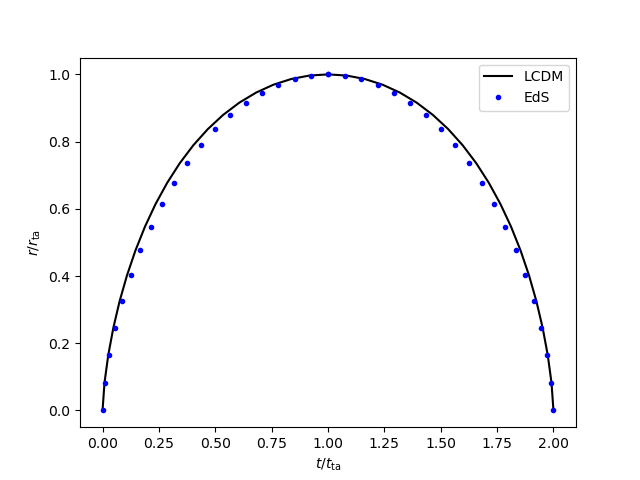

In [4]:
s1=SCSolver(0.3)
s2=SCSolver(1)

r=np.sin(np.linspace(0, np.pi/2, 20))
t1=np.array([s.RadiusTimer(x) for x in r])
t2=np.array([s2.RadiusTimer(x) for x in r])

plt.figure()
plt.plot(t1, r, 'k', label='LCDM')
plt.plot(2-t1, r, 'k')
plt.plot(t2, r, 'b.', label='EdS')
plt.plot(2-t2, r, 'b.')
plt.legend()
plt.xlabel(r'$t/t_{\rm ta}$')
plt.ylabel(r'$r/r_{\rm ta}$')

## Example Usage of `ReducedOrbit` class for self-similar orbit calculation

In [5]:
from SpheriC import ReducedOrbit

### solve the orbit following the self-similar model
- `epsilon`: initial perturbation profile slope. 
- `j` is a small reduced angular momentum, introduced to work around the divergence of orbital integration at the origin.
- `rconv` is the convergence radius (normalized by current turnaround radius), so that the final profile is converged at $r>rconv$.

* Tip: 

  - if your integration exceeds `max_iter` or `min_step`, try setting `j` and `rconv` to large values first and call `solve()`, to get a rough initial mass profile. then set rconv (and j) to smaller values and solve again (e.g., calling `orb.solve(rcov=1e-3)` again), to refine the solution. subsequent calls to `solve` will continue from previous state.

  - Alternatively, you can set j=0 to disable angular momentum. in this case, a reflecting boundary will be adopted around the origin (for lambda<atol), where atol is the error tolerance in the integrated orbit.  

/home/jxhan/Projects/DepletionRadius/SpheriC/SpheriC/SelfSimilarModel_FG84.py:304: RuntimeWarning: invalid value encountered in true_divide
  self.vlambd_pre=np.pi/2*np.sin(phi)/(1-np.cos(phi))


integrating..
r_apo, n_orbits:
0.012665963214221936 30.0
0.008333231493619617 45.0
0.005506936690928615 67.5
0.0036284888309445315 101.25
mass profile iteration 1, relative profile error=1.88e-01
integrating..
r_apo, n_orbits:
0.014389481074937966 30.0
0.009509773540778714 45.0
0.006302061546357028 67.5
0.0041367503684996915 101.25
mass profile iteration 2, relative profile error=3.82e-02


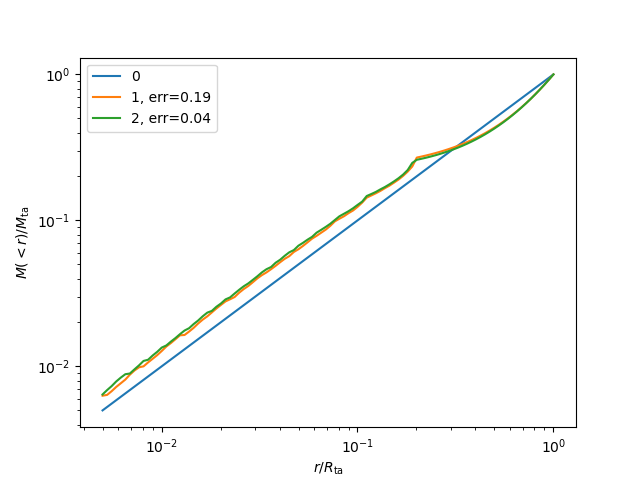

In [6]:
orb=ReducedOrbit(epsilon=0.3, j=1e-2)
orb.solve(rconv=5e-3)

In [7]:
# outdir='./plots/epsilon%.1f'%orb.epsilon

In [8]:
orb.locate_bounds()
rcusp=(orb.lambd/orb.Lambd)[orb.ind_caustic]
rapo=(orb.lambd/orb.Lambd)[orb.ind_apo]
print('outermost and innermost (resolved) caustic locations: ', rcusp[0], rcusp[-1])

outermost and innermost (resolved) caustic locations:  0.19072576149050033 0.0041367503684996915


### Plot various profiles

(0.004995278329433828, 1.2870410403835948)

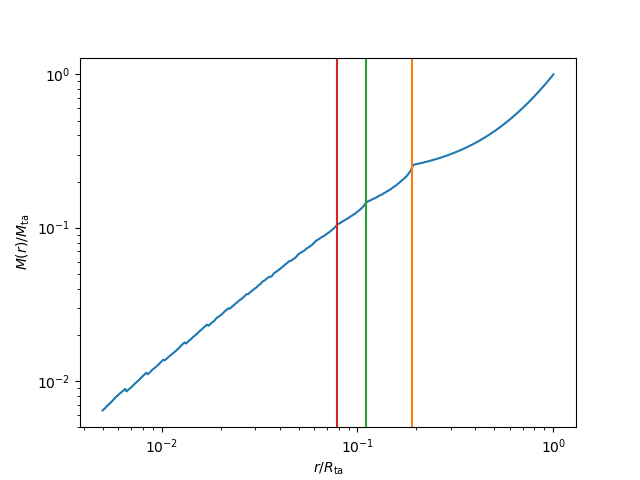

In [9]:
x1=np.logspace(np.log10(orb.rmin),0,320)
plt.figure()
plt.loglog(x1, orb.GetMass(x1))
#plt.plot(x1, orb2.GetMass(x1), 'g')
plt.xlabel(r'$r/R_{\rm ta}$')
plt.ylabel(r'$M(r)/M_{\rm ta}$')
ylim=plt.ylim()
for i in range(0,3):
    plt.plot(rcusp[i]*np.ones(2), ylim)
    #plt.plot(rapo[i+1]*np.ones(2), plt.ylim(),'--')
plt.ylim(ylim)

Text(0, 0.5, '$\\rho(r)/\\rho_{\\rm ta}$')

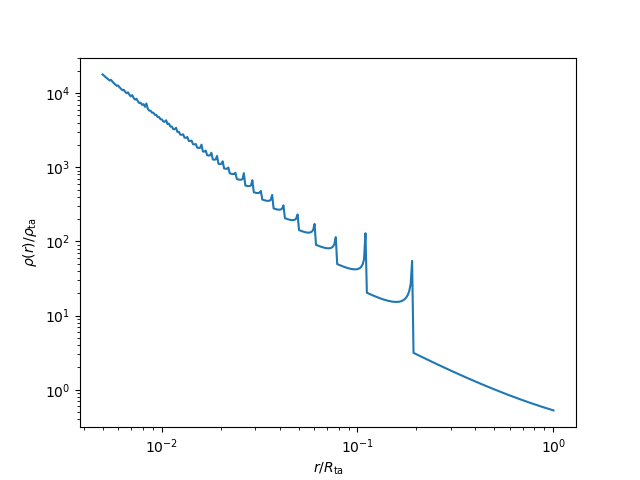

In [10]:
plt.figure()
plt.loglog(x1, orb.GetDensity(x1))
#for i in range(0,4):
#    plt.plot(rcusp[i]*np.ones(2), plt.ylim())
    #plt.plot(rapo[i+1]*np.ones(2), plt.ylim(),'--')
plt.xlabel(r'$r/R_{\rm ta}$')
plt.ylabel(r'$\rho(r)/\rho_{\rm ta}$')

Text(0, 0.5, '$\\mu(r)/\\mu_{\\rm ta}$')

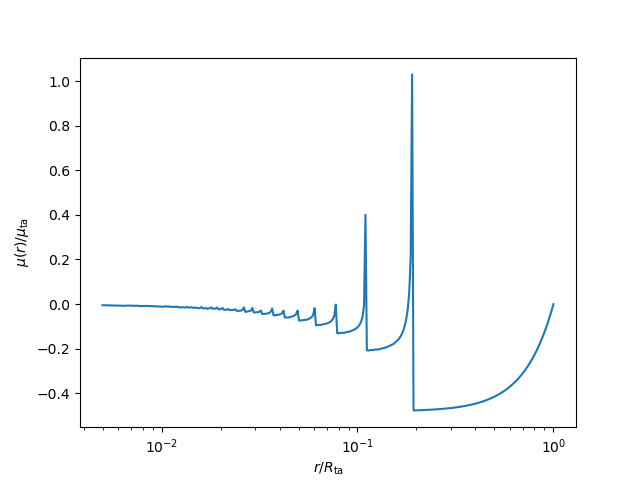

In [11]:
plt.figure()
plt.plot(x1, orb.GetMFR(x1),'-')
#for i in range(0,4):
#    plt.plot(rcusp[i]*np.ones(2), plt.ylim())
    #plt.plot(rapo[i+1]*np.ones(2), plt.ylim(),'--')
plt.xscale('log')
plt.xlabel(r'$r/R_{\rm ta}$')
plt.ylabel(r'$\mu(r)/\mu_{\rm ta}$')

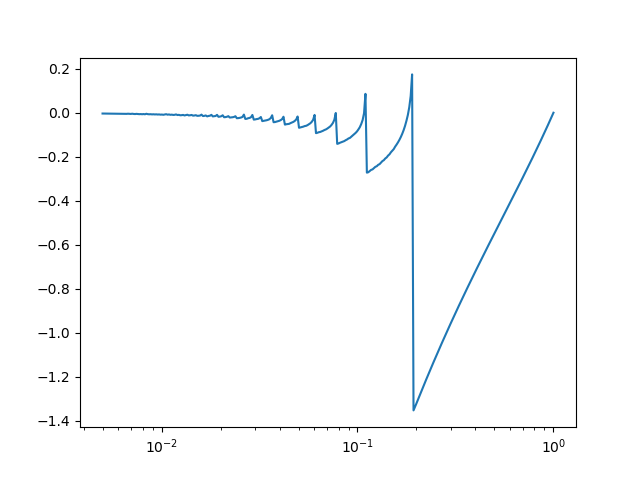

In [12]:
plt.figure()
plt.plot(x1, orb.GetVel(x1),'-')
plt.xscale('log')

In [13]:
plt.xlabel(r'$r/R_{\rm ta}$')
plt.ylabel(r'$v(r)/V_{\rm ta}$')

Text(30.972222222222214, 0.5, '$v(r)/V_{\\rm ta}$')

### Plot orbits and phase-space snapshots

In [14]:
#compute orbit prior to shell-crossing
orb.PreCollapse(np.pi*2)

#### time evolution of the orbit

Text(0.5, 0, '$\\lambda$')

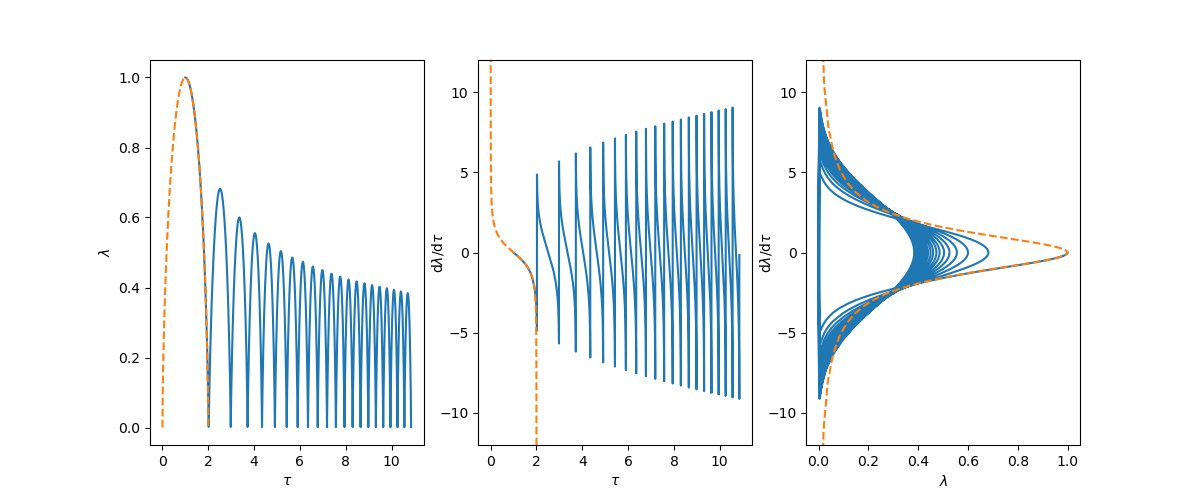

In [15]:
imax=orb.ind_peri[20]

plt.figure(figsize=(12,5))
plt.subplot(131)
plt.plot(orb.tau[:imax], orb.lambd[:imax])
plt.plot(orb.tau_pre, orb.lambd_pre, '--')
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\lambda$')
plt.subplot(132)
plt.plot(orb.tau[:imax], orb.vlambd[:imax])
plt.plot(orb.tau_pre, orb.vlambd_pre, '--')
plt.ylim([-12,12])
plt.xlabel(r'$\tau$')
plt.ylabel(r'$\mathrm{d}\lambda/\mathrm{d}\tau$', labelpad=-5)
plt.subplot(133)
plt.plot(orb.lambd[:imax],orb.vlambd[:imax])
plt.plot(orb.lambd_pre, orb.vlambd_pre, '--')
plt.ylim([-12,12])
plt.ylabel(r'$\mathrm{d}\lambda/\mathrm{d}\tau$',labelpad=-5)
plt.xlabel(r'$\lambda$')

#### phase space distributions of different mass shells at a fixed t. Now $\tau$ is a label for the different initial mass shells

/opt/conda/conda-4.12.0/envs/python3/lib/python3.7/site-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in true_divide
  
/opt/conda/conda-4.12.0/envs/python3/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in true_divide
  
/opt/conda/conda-4.12.0/envs/python3/lib/python3.7/site-packages/ipykernel_launcher.py:20: RuntimeWarning: invalid value encountered in true_divide


Text(0, 0.5, '$v/V_{\\rm ta}$')

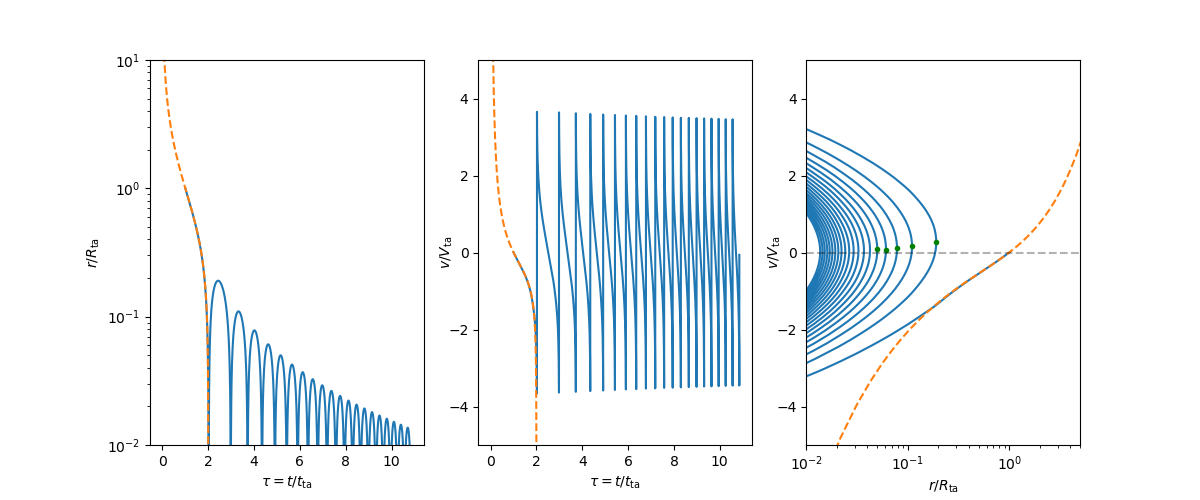

In [16]:
ind_apo0=orb.ind_caustic[:5]
ind_apo1=orb.ind_apo[:5]
plt.figure(figsize=(12,5))
plt.subplot(131)
plt.plot(orb.tau[:imax], (orb.lambd/orb.Lambd)[:imax])
plt.plot(orb.tau_pre, orb.lambd_pre/orb.Lambd_pre, '--')
#plt.plot(orb.tau[ind_apo1], (orb.lambd/orb.Lambd)[ind_apo1], '.')
plt.xlabel(r'$\tau=t/t_{\rm ta}$')
plt.ylabel(r'$r/R_{\rm ta}$')
plt.yscale('log')
plt.ylim([1e-2, 10])
plt.subplot(132)
plt.plot(orb.tau[:imax], (orb.vlambd/(orb.Lambd/orb.tau))[:imax])
plt.plot(orb.tau_pre, orb.vlambd_pre/(orb.Lambd_pre/orb.tau_pre), '--')
plt.ylim([-5,5])
plt.xlabel(r'$\tau=t/t_{\rm ta}$')
plt.ylabel(r'$v/V_{\rm ta}$',labelpad=-5)
plt.subplot(133)
plt.plot((orb.lambd/orb.Lambd)[:imax],(orb.vlambd/(orb.Lambd/orb.tau))[:imax])
plt.plot(orb.lambd_pre/orb.Lambd_pre, orb.vlambd_pre/(orb.Lambd_pre/orb.tau_pre), '--')
#plt.plot((orb.lambd/orb.Lambd)[ind_apo1],(orb.vlambd/(orb.Lambd/orb.tau))[ind_apo1],'r.')
plt.plot((orb.lambd/orb.Lambd)[ind_apo0],(orb.vlambd/(orb.Lambd/orb.tau))[ind_apo0],'g.')
plt.plot([1e-2,5], [0,0],'k--', alpha=0.3)
plt.xlim([1e-2,5])
plt.ylim([-5,5])
plt.xscale('log')
plt.xlabel(r'$r/R_{\rm ta}$')
plt.ylabel(r'$v/V_{\rm ta}$',labelpad=-5)

### check conservation of action

Text(0, 0.5, 'Radial Action')

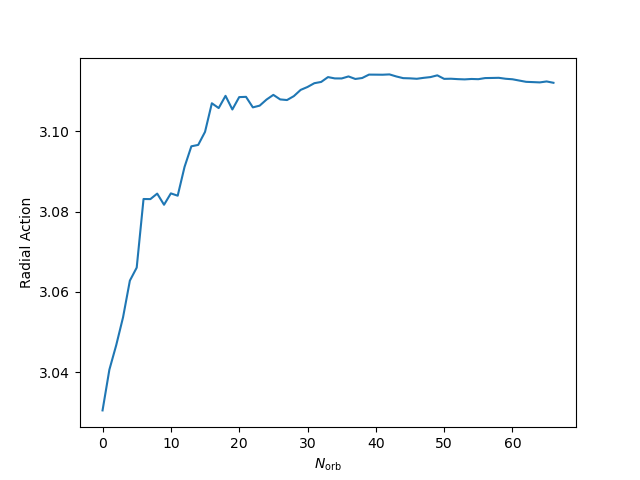

In [17]:
orb.GetActions()
plt.figure()
plt.plot(orb.actions)
plt.xlabel(r'$N_{\rm orb}$')
plt.ylabel('Radial Action')